In [25]:
import pandas as pd

df = pd.read_csv("../data/Preprocessed_data.csv")
df.head()

,station,Date,Present_Tmax,Present_Tmin,LDAPS_RHmin,LDAPS_RHmax,LDAPS_Tmax_lapse,LDAPS_Tmin_lapse,LDAPS_WS,LDAPS_LH,...,LDAPS_PPT2,LDAPS_PPT3,LDAPS_PPT4,lat,lon,DEM,Slope,Solar radiation,Next_Tmax,Next_Tmin
0,1.0,2013-06-30,28.7,21.4,58.255688,91.116364,28.074101,23.006936,6.818887,69.451805,...,0.0,0.0,0.0,37.6046,126.991,212.3350,2.7850,5992.895996,29.1,21.2
1,2.0,2013-06-30,31.9,21.6,52.263397,90.604721,29.850689,24.035009,5.691890,51.937448,...,0.0,0.0,0.0,37.6046,127.032,44.7624,0.5141,5869.312500,30.5,22.5
2,3.0,2013-06-30,31.6,23.3,48.690479,83.973587,30.091292,24.565633,6.138224,20.573050,...,0.0,0.0,0.0,37.5776,127.058,33.3068,0.2661,5863.555664,31.1,23.9
3,4.0,2013-06-30,32.0,23.4,58.239788,96.483688,29.704629,23.326177,5.650050,65.727144,...,0.0,0.0,0.0,37.6450,127.022,45.7160,2.5348,5856.964844,31.7,24.3
4,5.0,2013-06-30,31.4,21.9,56.174095,90.155128,29.113934,23.486480,5.735004,107.965535,...,0.0,0.0,0.0,37.5507,127.135,35.0380,0.5055,5859.552246,31.2,22.5


In [26]:
X = df.drop(['Next_Tmax','Next_Tmin','Date'], axis=1)
y = df[['Next_Tmax','Next_Tmin']]

X.shape, y.shape

((7723, 22), (7723, 2))

In [27]:
df = df.sort_values('Date')

split_index = int(0.8 * len(df))

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train.drop(['Next_Tmax','Next_Tmin','Date'], axis=1)
y_train = train[['Next_Tmax','Next_Tmin']]

X_test = test.drop(['Next_Tmax','Next_Tmin','Date'], axis=1)
y_test = test[['Next_Tmax','Next_Tmin']]

X_train.shape, X_test.shape

((6178, 22), (1545, 22))

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape

((6178, 22), (1545, 22))

In [29]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

# Explained variance
explained_variance = np.cumsum(pca.explained_variance_ratio_)

explained_variance

array([0.23192287, 0.36400425, 0.44794183, 0.5138546 , 0.57866054,
       0.6313886 , 0.67832954, 0.7220321 , 0.76143175, 0.79880998,
       0.83470058, 0.86579315, 0.89553656, 0.92239373, 0.93969144,
       0.95447099, 0.96610666, 0.9771872 , 0.98493599, 0.99117484,
       0.9971676 , 1.        ])

In [30]:
pca = PCA(n_components=15)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

X_train_pca.shape, X_test_pca.shape

((6178, 15), (1545, 15))

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train_pca, y_train)

y_pred = model.predict(X_test_pca)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

rmse, r2

(1.4510835494137617, 0.7674742028457551)

In [32]:
rmse_tmax = np.sqrt(mean_squared_error(y_test['Next_Tmax'], y_pred[:,0]))
rmse_tmin = np.sqrt(mean_squared_error(y_test['Next_Tmin'], y_pred[:,1]))

rmse_tmax, rmse_tmin

(1.804812168011604, 0.9766985066824543)

In [33]:
model_no_pca = LinearRegression()
model_no_pca.fit(X_train_scaled, y_train)

y_pred_no_pca = model_no_pca.predict(X_test_scaled)

rmse_tmax = np.sqrt(mean_squared_error(y_test['Next_Tmax'], y_pred_no_pca[:,0]))
rmse_tmin = np.sqrt(mean_squared_error(y_test['Next_Tmin'], y_pred_no_pca[:,1]))

rmse_tmax, rmse_tmin

(1.7389595523396983, 0.906807153926613)

In [34]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_tmax = np.sqrt(mean_squared_error(y_test['Next_Tmax'], y_pred_rf[:,0]))
rmse_tmin = np.sqrt(mean_squared_error(y_test['Next_Tmin'], y_pred_rf[:,1]))

rmse_tmax, rmse_tmin

(1.859802247030111, 0.9276406705143069)

In [35]:
# Create error targets
y_train_error = y_train.copy()
y_test_error = y_test.copy()

y_train_error['Tmax_error'] = y_train['Next_Tmax'] - train['LDAPS_Tmax_lapse']
y_train_error['Tmin_error'] = y_train['Next_Tmin'] - train['LDAPS_Tmin_lapse']

y_test_error['Tmax_error'] = y_test['Next_Tmax'] - test['LDAPS_Tmax_lapse']
y_test_error['Tmin_error'] = y_test['Next_Tmin'] - test['LDAPS_Tmin_lapse']

y_train_error[['Tmax_error','Tmin_error']].head()

,Tmax_error,Tmin_error
0,1.025899,-1.806936
24,2.036247,-0.772864
23,1.955748,-1.156806
22,2.942019,-1.533711
21,3.411130,-0.101352


In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

model_error = LinearRegression()
model_error.fit(X_train_scaled, y_train_error[['Tmax_error','Tmin_error']])

y_pred_error = model_error.predict(X_test_scaled)

# Reconstruct final predictions
y_pred_final_tmax = y_pred_error[:,0] + test['LDAPS_Tmax_lapse'].values
y_pred_final_tmin = y_pred_error[:,1] + test['LDAPS_Tmin_lapse'].values

# RMSE
rmse_tmax = np.sqrt(mean_squared_error(y_test['Next_Tmax'], y_pred_final_tmax))
rmse_tmin = np.sqrt(mean_squared_error(y_test['Next_Tmin'], y_pred_final_tmin))

rmse_tmax, rmse_tmin

(1.7389595523397001, 0.9068071539266126)

In [37]:
rf_error = RandomForestRegressor(n_estimators=100, random_state=42)
rf_error.fit(X_train, y_train_error[['Tmax_error','Tmin_error']])

y_pred_error_rf = rf_error.predict(X_test)

# Reconstruct
y_pred_final_tmax = y_pred_error_rf[:,0] + test['LDAPS_Tmax_lapse'].values
y_pred_final_tmin = y_pred_error_rf[:,1] + test['LDAPS_Tmin_lapse'].values

rmse_tmax = np.sqrt(mean_squared_error(y_test['Next_Tmax'], y_pred_final_tmax))
rmse_tmin = np.sqrt(mean_squared_error(y_test['Next_Tmin'], y_pred_final_tmin))

rmse_tmax, rmse_tmin

(1.8098746056107553, 0.8924564952110848)

In [38]:
import pandas as pd

importance = rf.feature_importances_
feature_names = X_train.columns

feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)

feat_imp.head(10)

LDAPS_Tmax_lapse    0.445534
LDAPS_Tmin_lapse    0.256206
Present_Tmax        0.043541
Present_Tmin        0.040896
LDAPS_CC1           0.030503
LDAPS_WS            0.023308
LDAPS_CC2           0.021352
Solar radiation     0.019825
LDAPS_CC3           0.017670
LDAPS_CC4           0.017367
dtype: float64

In [39]:
df_ts = df[df['station'] == 1].copy()
df_ts = df_ts.sort_values('Date')

df_ts[['Date','Next_Tmax']].head()

,Date,Next_Tmax
0,2013-06-30,29.1
25,2013-07-01,24.8
50,2013-07-02,28.1
75,2013-07-03,25.2
100,2013-07-04,28.0


In [40]:
df_ts['Date'] = pd.to_datetime(df_ts['Date'])
df_ts.set_index('Date', inplace=True)

ts = df_ts['Next_Tmax']

ts.head()

Date
2013-06-30    29.1
2013-07-01    24.8
2013-07-02    28.1
2013-07-03    25.2
2013-07-04    28.0
Name: Next_Tmax, dtype: float64

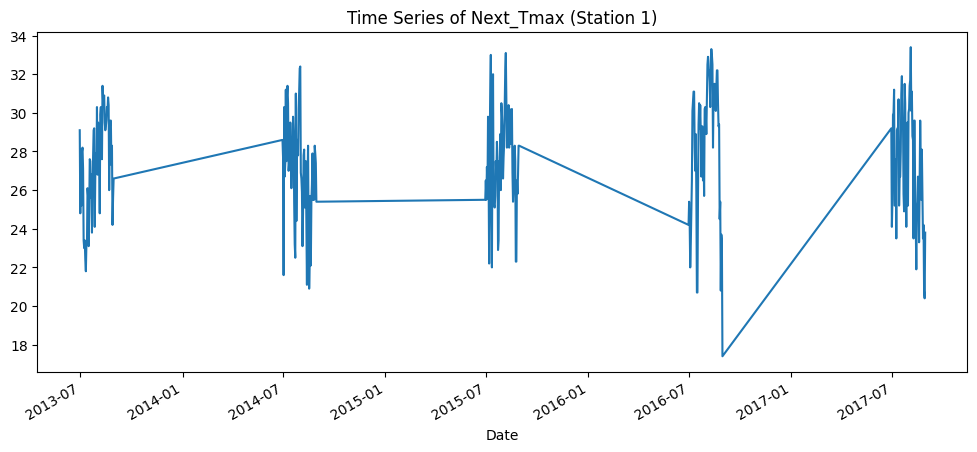

In [41]:
import matplotlib.pyplot as plt

ts.plot(figsize=(12,5))
plt.title("Time Series of Next_Tmax (Station 1)")
plt.show()

In [42]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -5.958670378542549
p-value: 2.0639163785536102e-07


In [43]:
ts_season = ts['2013-06-30':'2013-08-30']

from statsmodels.tsa.stattools import adfuller

result = adfuller(ts_season)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.5800639625388502
p-value: 0.49359981947185083


In [44]:
ts_diff = ts_season.diff().dropna()
ts_diff = ts_season.diff().dropna()


from statsmodels.tsa.stattools import adfuller

result = adfuller(ts_diff)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -6.991417276549754
p-value: 7.727466040068494e-10


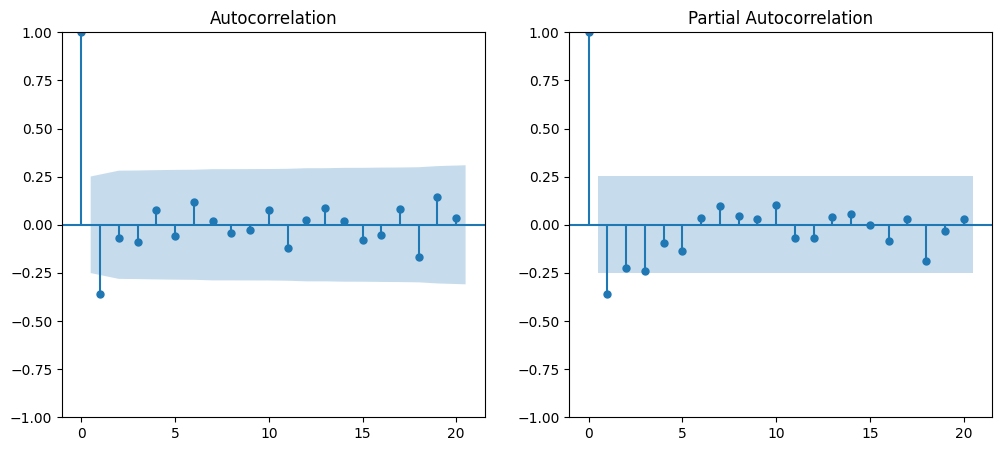

In [45]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(ts_diff, ax=plt.gca(), lags=20)

plt.subplot(1,2,2)
plot_pacf(ts_diff, ax=plt.gca(), lags=20)

plt.show()

In [46]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts_season, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              Next_Tmax   No. Observations:                   62
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -126.756
Date:                Fri, 10 Apr 2026   AIC                            259.513
Time:                        18:34:24   BIC                            265.845
Sample:                    06-30-2013   HQIC                           261.995
                         - 08-30-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1349      0.259      0.521      0.602      -0.373       0.642
ma.L1         -0.6831      0.196     -3.479      0.001      -1.068      -0.298
sigma2         3.7085      0.742      5.000      0.0

C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [47]:
forecast = model_fit.predict(start=1, end=len(ts_season)-1)

actual = ts_season[1:]

from sklearn.metrics import mean_squared_error
import numpy as np

rmse_arima = np.sqrt(mean_squared_error(actual, forecast))

rmse_arima

1.9466658507136545

In [48]:
df_ts = df[df['station'] == 1].copy()
df_ts = df_ts.sort_values('Date')

df_ts['Date'] = pd.to_datetime(df_ts['Date'])
df_ts.set_index('Date', inplace=True)

ts = df_ts['Next_Tmax']

ts.head()

Date
2013-06-30    29.1
2013-07-01    24.8
2013-07-02    28.1
2013-07-03    25.2
2013-07-04    28.0
Name: Next_Tmax, dtype: float64

In [49]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(ts, order=(1,1,1), seasonal_order=(1,1,1,60))
model_sarima_fit = model_sarima.fit(disp=False)

print(model_sarima_fit.summary())

C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                          Next_Tmax   No. Observations:                  310
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 60)   Log Likelihood                -622.336
Date:                            Fri, 10 Apr 2026   AIC                           1254.671
Time:                                    18:35:03   BIC                           1272.259
Sample:                                         0   HQIC                          1261.751
                                            - 310                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4450      0.066      6.709      0.000       0.315       0.575
ma.L1         -0.9334      0.036   

In [50]:
forecast = model_sarima_fit.predict(start=1, end=len(ts)-1)

actual = ts[1:]

from sklearn.metrics import mean_squared_error
import numpy as np

rmse_sarima = np.sqrt(mean_squared_error(actual, forecast))

rmse_sarima

2.914673732247205

In [51]:
exog = df_ts[['LDAPS_Tmax_lapse', 'LDAPS_RHmax', 'LDAPS_WS', 'Solar radiation']]
target = df_ts['Next_Tmax']

exog.head()

,LDAPS_Tmax_lapse,LDAPS_RHmax,LDAPS_WS,Solar radiation
Date,,,,
2013-06-30,28.074101,91.116364,6.818887,5992.895996
2013-07-01,25.276716,97.642792,15.608045,5987.718750
2013-07-02,27.785497,98.370041,11.168633,5981.979492
2013-07-03,28.125651,95.990532,10.546499,5975.676270
2013-07-04,30.458252,97.402481,7.393145,5968.809082


In [52]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarimax = SARIMAX(target, exog=exog, order=(1,1,1))
model_sarimax_fit = model_sarimax.fit(disp=False)

print(model_sarimax_fit.summary())

C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              Next_Tmax   No. Observations:                  310
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -540.021
Date:                Fri, 10 Apr 2026   AIC                           1094.042
Time:                        18:35:04   BIC                           1120.176
Sample:                             0   HQIC                          1104.491
                                - 310                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
LDAPS_Tmax_lapse     0.8509      0.037     22.701      0.000       0.777       0.924
LDAPS_RHmax         -0.0112      0.015     -0.734      0.463      -0.041       0.019
LDAPS_WS            -0.1308 

C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [53]:
forecast = model_sarimax_fit.predict(start=1, end=len(target)-1, exog=exog.iloc[1:])

actual = target[1:]

from sklearn.metrics import mean_squared_error
import numpy as np

rmse_sarimax = np.sqrt(mean_squared_error(actual, forecast))

rmse_sarimax

1.3875193722711612